In [ ]:
# Todas las librerías utilizadas para este Notebook:
import os
import argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from nfoursid.nfoursid import NFourSID
from KF import DiscreteKalmanFilter

## 1. Carga y preprocesamiento de los datos

De la comunicación con las Jetson Nano mediante OPC UA se obtuvo un .csv. Este tiene los voltaje introducidos $u_i$, las temperaturas de salida medidas $y_i$ y la temperatura externa del edificio (perturbación). Sin embargo, como N4SID asume que las muestras se encuentran igualmente espaciadas en el tiempo, es importante procesar la información recopilada para identificar y corregir si corresponde, retrasos o fallos por la comunicación OPC

In [10]:
# Cargamos el .csv obtenido:
data_frame = pd.read_csv("datos_identificacion_planta_3.csv")

# Filtramos posibles valores repetidos y datos NaN, Null:
steps = set(data_frame["step"].dropna().unique())

# Creamos el arreglo ideal según el rango definido:
step_min = int(data_frame["step"].min())
step_max = int(data_frame["step"].max())
arreglo_ideal = set(range(step_min, step_max + 1))

# Identificamos qué datos se perdieron: 
steps_perdidos = arreglo_ideal - steps

# Prints para debug:
print("Muestras registradas :", len(data_frame))
print("Muestras esperadas :", len(arreglo_ideal))
print("Muestras perdidas :", len(steps_perdidos))

Muestras registradas : 5185
Muestras esperadas : 7500
Muestras perdidas : 2315


En caso de haber pérdidas, se debe reindexar y hacer una interpolación lineal de los valores:

In [ ]:

# Para reindexar se crea una grilla uniforme ordenada con list(), que es el formato que Pandas pide:
grilla_uniforme = sorted(list(arreglo_ideal))

# Reindexamos los step a la nueva grilla:
df_reindexado = data_frame.set_index("step").reindex(grilla_uniforme)

# Seleccionamos las columnas de las entradas (v1, v2, v3, v4, v5):
u_cols = [nombre for nombre in df_reindexado.columns if nombre.startswith("v")]
# Reemplazamos los datos faltantes de entradas con el último valor conocido:
df_reindexado[u_cols] = df_reindexado[u_cols].ffill()

# Proceso similar, pero en vez de mantener valor, interpolamos:
t_cols = [nombre for nombre in df_reindexado.columns if nombre.startswith("T") or nombre == "Tout"]
df_reindexado[t_cols] = df_reindexado[t_cols].interpolate(method="linear")

# Volvemos a "step" como una columna normal (en vez de "index")
df_reindexado.index.name = "step"
df_final = df_reindexado.reset_index()

# Print para debug: 

print(f"Dimensiones originales (filas, columnas): {data_frame.shape}")
print(f"Dimensiones finales (filas, columnas)   : {df_final.shape}")

if steps_perdidos:
    # Step de ejemplo para visualizar corrección:
    step_ejemplo = list(steps_perdidos)[0]
    
    # Encontramos qué tan grande es el "bache" de steps perdidos
    bache_completo = []
    p = step_ejemplo
    while p in steps_perdidos:
        bache_completo.append(p)
        p += 1
        
    # Agregamos un paso antes y un paso después del bache completo
    step_anterior = min(bache_completo) - 1
    step_posterior = max(bache_completo) + 1
    rango_a_mostrar = [step_anterior] + bache_completo + [step_posterior]
    
    print(f" Primeros steps recuperados: {bache_completo}):")
    filtro_vecinos = df_final["step"].isin(rango_a_mostrar)
    print(df_final[filtro_vecinos].to_string(index=False))
else:
    print("No había pasos perdidos, mostrando el inicio:")
    print(df_final.head(3).to_string(index=False))

Dimensiones originales (filas, columnas): (5185, 14)
Dimensiones finales (filas, columnas)   : (7500, 14)
 Steps recuperados: [3, 4]):
 step      v1        v2       v3        v4        v5        v6        T1        T2        T3        T4        T5        T6      Tout
    2 0.05398 -0.774864 0.944587 -0.374086 -0.595336 -0.645321 23.513839 20.264346 27.499628 23.332494 23.757553 19.483969 22.475000
    3 0.05398 -0.774864 0.944587 -0.374086 -0.595336 -0.645321 23.486247 20.134554 27.687029 23.203471 23.435443 19.398703 22.462778
    4 0.05398 -0.774864 0.944587 -0.374086 -0.595336 -0.645321 23.458656 20.004763 27.874429 23.074448 23.113334 19.313436 22.450556
    5 0.05398 -0.774864 0.944587 -0.374086 -0.595336 -0.645321 23.431064 19.874972 28.061830 22.945425 22.791224 19.228170 22.438333


Luego, definimos las entradas y salidas del sistema que serán luego entregadas a la librería de N4SID:

In [ ]:
# Definimos las columnas de voltaje (entradas de control)
volt_cols = [c for c in df_final.columns if c.startswith('v')]

# Definimos las temperaturas de las piezas (salidas del sistema)
room_cols = [c for c in df_final.columns if c.startswith('T') and c != 'Tout']

# Construimos los vectores para N4SID:
u_cols = volt_cols + ['Tout']  # Entradas (Actuadores + Perturbación externa)
y_cols = room_cols             # Salidas (Temperaturas internas a controlar)

# Prints debug:
print("\n--- Primeros valores matriz de entradas (u) ---")
print(df_final[u_cols].head(3).to_string(index=False))
print("\n--- Primeros valores matriz de salidas (y) ---")
print(df_final[y_cols].head(3).to_string(index=False))


--- Primeros valores matriz de entradas (u) ---
     v1        v2       v3        v4        v5        v6   Tout
0.05398 -0.774864 0.944587 -0.374086 -0.595336 -0.645321 22.530
0.05398 -0.774864 0.944587 -0.374086 -0.595336 -0.645321 22.530
0.05398 -0.774864 0.944587 -0.374086 -0.595336 -0.645321 22.475

--- Primeros valores matriz de salidas (y) ---
       T1        T2        T3        T4        T5        T6
23.641744 22.510047 23.762969 24.453070 26.493545 20.055340
23.655430 21.820066 24.975132 24.113399 25.685447 19.906989
23.513839 20.264346 27.499628 23.332494 23.757553 19.483969


In [34]:
# RESUMEN DEL PRIMER MÓDULO:
import pandas as pd

def preparar_datos(ruta_csv):
    data_frame = pd.read_csv(ruta_csv)
    
    # Se ignora el sim_step si existe:
    data_frame = data_frame.drop(columns=["sim_step"], errors="ignore")

    step_min = int(data_frame["step"].min())
    step_max = int(data_frame["step"].max())
    grilla_uniforme = list(range(step_min, step_max + 1))

    steps_perdidos = len(grilla_uniforme) - len(data_frame)

    if steps_perdidos > 0:
        print(f"Se detectaron {steps_perdidos} steps perdidos. Aplicando reparación...")

        df_reindexado = data_frame.set_index("step").reindex(grilla_uniforme)

        v_cols = [nombre for nombre in df_reindexado.columns
                  if nombre.startswith("v")]
        df_reindexado[v_cols] = df_reindexado[v_cols].ffill()

        t_cols = [nombre for nombre in df_reindexado.columns
                  if nombre.startswith("T") or nombre == "Tout"]
        df_reindexado[t_cols] = df_reindexado[t_cols].interpolate(method="linear")

        df_reindexado.index.name = "step"
        df_final = df_reindexado.reset_index()

    else:
        print("No se detectaron steps perdidos. No se requiere reparación.")
        df_final = data_frame.copy()

    volt_cols = [c for c in df_final.columns if c.startswith('v')]
    room_cols = [c for c in df_final.columns
                 if c.startswith('T') and c != 'Tout']

    u_cols = volt_cols + ['Tout']
    y_cols = room_cols

    u_df = df_final[u_cols]
    y_df = df_final[y_cols]

    return df_final, u_df, y_df

# LLAMADA DATA_FRAME 1:
print("============ DATOS DEL EDIFICIO 2 ============")
df_completo1, u1, y1 = preparar_datos("datos_identificacion_planta_2.csv")
print(f"Datos completos (primeras 3 filas) : {df_completo1.shape}")
display(df_completo1.head(3))
print("Primeras 3 entradas utilizadas:")
display(u1.head(3))
print("Primeras 3 salidas utilizadas:")
display(y1.head(3))

# LLAMADA DATA_FRAME 3:
print("============ DATOS DEL EDIFICIO 3 ============")
df_completo2, u2, y2 = preparar_datos("datos_identificacion_planta_3.csv")
print(f"Datos completos (primeras 3 filas) : {df_completo2.shape}")
display(df_completo2.head(3))
print("Primeras 3 entradas utilizadas:")
display(u2.head(3))
print("Primeras 3 salidas utilizadas:")
display(y2.head(3))

# LLAMADA DATA_FRAME 3:
print("============ DATOS DEL EDIFICIO 4 ============")
df_completo3, u3, y3 = preparar_datos("datos_identificacion_planta_4.csv")
print(f"Datos completos (primeras 3 filas) : {df_completo3.shape}")
display(df_completo3.head(3))
print("Primeras 3 entradas utilizadas:")
display(u3.head(3))
print("Primeras 3 salidas utilizadas:")
display(y3.head(3))

============ DATOS DEL EDIFICIO 2 ============
No se detectaron steps perdidos. No se requiere reparación.
Datos completos (primeras 3 filas) : (7500, 14)


,step,v1,v2,v3,v4,v5,v6,T1,T2,T3,T4,T5,T6,Tout
0,0,-0.16676,-0.979662,0.650413,-0.40272,-0.263177,-0.612677,24.864660,26.766959,24.780699,22.952496,30.906976,21.422785,28.583333
1,1,-0.16676,-0.979662,0.650413,-0.40272,-0.263177,-0.612677,25.444317,27.117641,24.780699,22.952496,30.906976,21.422785,28.583333
2,2,-0.16676,-0.979662,0.650413,-0.40272,-0.263177,-0.612677,25.444317,27.117641,24.980632,22.688164,31.169536,21.528672,28.566667


Primeras 3 entradas utilizadas:


,v1,v2,v3,v4,v5,v6,Tout
0,-0.16676,-0.979662,0.650413,-0.40272,-0.263177,-0.612677,28.583333
1,-0.16676,-0.979662,0.650413,-0.40272,-0.263177,-0.612677,28.583333
2,-0.16676,-0.979662,0.650413,-0.40272,-0.263177,-0.612677,28.566667


Primeras 3 salidas utilizadas:


...

,step,v1,v2,v3,v4,v5,v6,T1,T2,T3,T4,T5,T6,Tout
0,0,-0.772099,0.798277,0.644691,0.354707,-0.010036,0.691899,22.302379,18.474523,25.760248,25.039246,27.118885,16.387241,-17.341667
1,1,-0.772099,0.798277,0.644691,0.354707,-0.010036,0.691899,21.640860,19.039463,25.638624,24.677705,26.240762,16.563152,-17.370000
2,2,-0.772099,0.798277,0.644691,0.354707,-0.010036,0.691899,20.979342,19.604404,25.517001,24.316164,25.362640,16.739063,-17.398333


Primeras 3 entradas utilizadas:


,v1,v2,v3,v4,v5,v6,Tout
0,-0.772099,0.798277,0.644691,0.354707,-0.010036,0.691899,-17.341667
1,-0.772099,0.798277,0.644691,0.354707,-0.010036,0.691899,-17.370000
2,-0.772099,0.798277,0.644691,0.354707,-0.010036,0.691899,-17.398333


Primeras 3 salidas utilizadas:


,T1,T2,T3,T4,T5,T6
0,22.302379,18.474523,25.760248,25.039246,27.118885,16.387241
1,21.640860,19.039463,25.638624,24.677705,26.240762,16.563152
2,20.979342,19.604404,25.517001,24.316164,25.362640,16.739063


Una vez completadas estas etapas de limpieza y organización de datos, el conjunto de mediciones se encuentra listo para la construcción de las matrices de Hankel y la aplicación del método N4SID.

### Aplicando N4SID
Todo lo que vimos antes pasa internamente en una función: Arma las matrices de Hankel, hace la proyección oblicua y el SVD. Lo único que debemos hacer es definir $i$ y entregarle los datos recogidos.

# 2. Identificación de Sistemas mediante N4SID y Filtro de Kalman

El método **N4SID (Numerical Subspace State Space System Identification)** permite obtener un modelo en espacio de estados directamente desde datos de entrada-salida.

El modelo discreto tiene la forma:

$$
x_{k+1}=Ax_k+Bu_k+w_k
$$

$$
y_k=Cx_k+Du_k+v_k
$$

donde:

- $x_k$: vector de estados (dimensión $n$, a determinar).
- $u_k$: entrada (en nuestro caso, los 6 voltajes $[v_1,\dots,v_6]^\top$).
- $y_k$: salida medida (las 6 temperaturas $[T_1,\dots,T_6]^\top$).
- $w_k$: ruido de proceso.
- $v_k$: ruido de medición.

El objetivo de N4SID es estimar las matrices $A,\;B,\;C,\;D$ y, de paso, el orden $n$ del sistema.

### Matrices de Hankel por bloques

La idea central de N4SID es reorganizar la serie temporal en **ventanas deslizantes** y luego extraer la estructura del sistema. Como cada muestra $u_k$ (o $y_k$) es un *vector* y no un escalar, cada entrada de la matriz es un **bloque** (por eso matriz de Hankel por **bloques**).

Nosotros escogemos el parámetro $i$ (el número de bloques por mitad) y se construye la matriz de entradas apilando $2i$ copias de la señal, cada una desplazada un paso en el tiempo:

$$
U_{0|2i-1}=
\begin{bmatrix}
u_0 & u_1 & \cdots & u_{j-1}\\
u_1 & u_2 & \cdots & u_{j}\\
\vdots & \vdots & \ddots & \vdots\\
u_{2i-1} & u_{2i} & \cdots & u_{2i+j-2}
\end{bmatrix}
=
\begin{bmatrix} U_p \\[2pt] U_f \end{bmatrix}
$$

Cada **columna** es una ventana de $2i$ pasos consecutivos, y cada columna avanza un paso respecto a la anterior. El número de columnas es $j = N - 2i + 1$, donde $N$ es el largo de los datos.

La matriz se parte en dos bloques horizontales:

- $U_p$ (las primeras $i$ filas de bloques): el **pasado** de las entradas.
- $U_f$ (las últimas $i$ filas de bloques): el **futuro** de las entradas.

La matriz de salidas $Y_{0|2i-1}$ se construye de forma idéntica con $y_k$, y se divide en $Y_p$ (pasado) y $Y_f$ (futuro). Finalmente se define el bloque de **datos pasados combinados**:

$$
W_p=\begin{bmatrix} U_p \\[2pt] Y_p \end{bmatrix}
$$

### ¿Cómo se construye el estado presente a partir del pasado y del futuro?

El estado $x_k$ es, por definición, un **resumen suficiente del pasado**: contiene toda la información necesaria para predecir el futuro del sistema. Por lo tanto, los datos pasados $W_p$ deben determinar el estado en el instante presente (la frontera entre el bloque pasado y el futuro de cada columna).

Esto se formaliza en dos relaciones. Primero, iterando las ecuaciones de estado hacia adelante, las **salidas futuras** se escriben como:

$$Y_f=\Gamma_i\,X_f+H_i\,U_f$$

donde:

- $X_f=\begin{bmatrix}x_k & x_{k+1} & \cdots & x_{k+j-1}\end{bmatrix}$ es la **secuencia de estados** en el instante frontera de cada columna,
- $\Gamma_i=\begin{bmatrix}C\\ CA\\ \vdots\\ CA^{\,i-1}\end{bmatrix}$ es la **matriz de observabilidad extendida**,

Básicamente, si en el instante $k$ el sistema está en el estado $x_k$ y "apagáramos" las entradas, las siguientes $i$ salidas serían

$$
\begin{bmatrix} y_k \\ y_{k+1} \\ y_{k+2} \\ \vdots \\ y_{k+i-1} \end{bmatrix}
=
\underbrace{\begin{bmatrix} C \\ CA \\ CA^2 \\ \vdots \\ CA^{\,i-1} \end{bmatrix}}_{\Gamma_i}\; x_k
$$

Cada bloque $CA^{p}$ responde "cómo se asoma en la salida el estado propagado \(p\) pasos".

- $H_i$ es una matriz de Toeplitz (constantes en las diagonales) con los parámetros de Markov ($D, CB, CAB,\dots$), que representa el efecto directo de las entradas futuras.

$$
H_i=
\begin{bmatrix}
D & 0 & 0 & \cdots & 0\\
CB & D & 0 & \cdots & 0\\
CAB & CB & D & \cdots & 0\\
\vdots & & \ddots & \ddots & \vdots\\
CA^{\,i-2}B & \cdots & CAB & CB & D
\end{bmatrix}
$$

Los bloques $D,\;CB,\;CAB,\;CA^2B,\dots$ (parámetros de Markov) son la **respuesta al impulso** del sistema discreto ($h_0=D$, $h_k=CA^{k-1}B$ para $k\ge 1$). Describen cómo un input aplicado en un instante dado afecta a las salidas de los instantes siguientes.


Ahora, como el estado es un resumen suficiente del pasado, si hay suficientes pasos previos ($i\ge n$ y el sistema es observable), se puede reconstruir el estado actual a partir de las entradas y salidas pasadas. Formalmente: del pasado $Y_p = \Gamma_i x_{k-i} + H_i U_p$ se despeja $x_{k-i}$, y luego se propaga hasta la frontera. Así, todo queda como combinación lineal de $U_p$ y $Y_p$. Esa combinación lineal es $L_p$:

$$
X_f \approx L_p\,W_p, \qquad W_p=\begin{bmatrix}U_p\\ Y_p\end{bmatrix}
$$

Aquí llegamos a lo clave: **la secuencia de estados $X_f$ vive en el espacio de filas de $W_p$**. Entonces solo queda el paso final:


## Proyección oblicua

Tenemos $Y_f = \Gamma_i X_f + H_i U_f$, donde el primer término vive en el espacio de $W_p$ (porque $X_f=L_p W_p$) y el segundo vive en el espacio de $U_f$. Queremos quedarnos solo con $\Gamma_i X_f$.

Si hiciéramos una proyección **ortogonal** sobre $W_p$, nos contaminaríamos: las entradas y los datos pasados suelen estar correlacionados, así que parte de $H_i U_f$ se "colaría" en la proyección. La proyección **oblicua** resuelve esto descomponiendo $Y_f$ a lo largo de dos direcciones no perpendiculares: $W_p$ y $U_f$. Y luego, se queda con la componente sobre $W_p$ *medida en la dirección de* $U_f$. Eso elimina todo lo explicable por $U_f$.

El resultado, en el caso sin ruido, es exacto:

$$
\mathcal{O}_i = Y_f \,/_{U_f}\, W_p = \Gamma_i X_f
$$

Y como $\mathcal{O}_i$ es ahora el producto observabilidad × estados, su SVD contiene el orden $n$ (cuántos valores singulares importan) y entrega la secuencia de estados $X_f$, que es lo que faltaba para luego sacar \(A,B,C,D\) por mínimos cuadrados.

### Preprocesamiento: normalización

Antes de identificar, normalizamos con un `StandardScaler`. Hay dos razones:
N4SID ajusta un modelo **lineal alrededor de un punto de operación**, así que
centrar en cero hace válida esa linealización, y escalar mejora el
condicionamiento del SVD y los mínimos cuadrados.

Además, como se pide en la guía, separamos primero el 80% de entrenamiento, ajustamos el
scaler **solo con ese tramo** y recién después transformamos todo.

In [ ]:
Train_fraction = 0.8 # fracción del conjunto a entrenar

# Retomamos los datos de antes (edificio 2 por ejemplo):
u_cols = list(u1.columns)
y_cols = list(y1.columns)
df_io  = pd.concat([u1, y1], axis=1)

# Separamos nuestros casos de entrenamiento antes de ajustar el scaler:
n_train = int(Train_fraction * len(df_io))

# Ajustar StandardScaler solo con train para evitar "data leakage":
su = StandardScaler().fit(df_io[u_cols].values[:n_train])
sy = StandardScaler().fit(df_io[y_cols].values[:n_train])

# Con la media y desviación de antes se hace la normalización:
U = su.transform(df_io[u_cols].values)
Y = sy.transform(df_io[y_cols].values)

# 4) Separar en train / validación:
U_tr, U_val = U[:n_train], U[n_train:]
Y_tr, Y_val = Y[:n_train], Y[n_train:]


### Aplicando N4SID

Todo el contenido teórico de N4SID que vimos antes pasa internamente en una función: arma las matrices de Hankel, hace la proyección oblicua y el SVD. Lo único que debemos hacer es
definir $i$ y entregarle los datos **normalizados**.

In [132]:
# DataFrame con columnas nombradas, SOLO con el train normalizado:
df_tr = pd.DataFrame(np.hstack([U_tr, Y_tr]), columns=u_cols + y_cols)

# Parámetro de historial i (número de bloques de Hankel):
i = 40

# Establecemos entradas y salidas del sistema:
modelo_n4sid = NFourSID(df_tr, input_columns=u_cols, output_columns=y_cols, num_block_rows=i)
modelo_n4sid.subspace_identification()   # Hankel + proyección oblicua + SVD

### Elegir el orden: método del codo

El SVD entrega los valores singulares. Buscamos el "codo": el punto donde dejan
de caer bruscamente. Los valores antes del codo son dinámica real; los de
después, ruido. La cantidad de valores grandes nos da el orden $n$

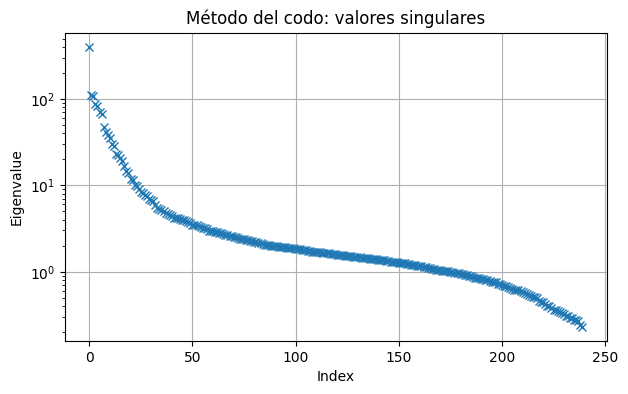

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
modelo_n4sid.plot_eigenvalues(ax)
ax.set_yscale('log') # escala log: el codo se ve mucho mejor
ax.set_title('Método del codo: valores singulares')
plt.show()

### Extraer el modelo

Elegido el orden mirando el gráfico, `system_identification` resuelve el ajuste
final por mínimos cuadrados y devuelve las matrices A, B, C, D más la covarianza
del ruido. La separamos en Q (proceso) y R (medición), que usa el filtro
de Kalman.

In [134]:
orden = 6   # Ajustar según el codo del gráfico anterior

modelo_ee, cov = modelo_n4sid.system_identification(rank=orden)
A, B, C, D = modelo_ee.a, modelo_ee.b, modelo_ee.c, modelo_ee.d

# nfoursid ordena la covarianza como [y(medición); x(proceso)]:
ny = len(y_cols)
R = cov[:ny, :ny]    # ruido de medición
Q = cov[ny:, ny:]    # ruido de proceso

### Formas y estabilidad de las matrices

Verificamos que el modelo sea **estable**: un sistema discreto lo es cuando todos sus polos —los eigenvalues de $A$— caen dentro del círculo unitario, es decir $|\lambda|<1$. Si algún polo se sale, la predicción libre diverge.

In [135]:

# Un sistema discreto es estable si todos sus polos (eigenvalues de A) cumplen |lambda| < 1
magnitudes = np.abs(np.linalg.eigvals(A))
print(f"\nMayor magnitud de polo |lambda|_max = {magnitudes.max():.4f}")
print("Modelo estable: todos los polos dentro del círculo unitario"
      if magnitudes.max() < 1 else
      "Modelo INESTABLE: hay polos fuera del círculo unitario")


Mayor magnitud de polo |lambda|_max = 0.9657
Modelo estable: todos los polos dentro del círculo unitario


### El filtro de Kalman y la evaluación

N4SID nos entregó las matrices $A, B, C, D$, pero el estado $x$ es una coordenada
interna abstracta: no la medimos. Para predecir sobre datos nuevos primero hay que
saber "dónde está parado" el sistema. Para eso usamos el filtro de Kalman: dada
la primera medición de temperaturas y voltajes, estima el estado inicial del modelo.

El protocolo de evaluación sigue el enunciado. Sobre cada ventana de 15 minutos del
conjunto de validación:

- **t = 1:** el filtro de Kalman corrige el estado una sola vez con la primera
  medición (la "semilla").
- **t = 2 … 15:** predicción libre, propagando solo el modelo
  ($x_{k+1} = A x_k + B u_k$, $\; y_k = C x_k + D u_k$) sin volver a mirar las
  temperaturas reales.

Comparamos las 14 predicciones contra lo que realmente ocurrió, en °C.

In [ ]:
nx, nu = A.shape[0], B.shape[1]

L = 15            # ventana de 15 minutos
H = L - 1         # 14 pasos de predicción libre (t=2...15)
n_win = len(U_val) - L + 1 # ventanas totales de validación

pred = np.zeros((n_win, H, ny)) # array para predicciones (espacio normalizado)
real = np.zeros((n_win, H, ny)) # array para valores reales

for ventana in range(n_win):
    u_w, y_w = U_val[ventana:ventana + L], Y_val[ventana:ventana + L] # el 20% restante

    # Semilla: estado inicial coherente con la primera medición (resolvemos y0 = C x + D u0).
    y0 = y_w[0].reshape(ny, 1)
    u0 = u_w[0].reshape(nu, 1)
    x0 = np.linalg.pinv(C) @ (y0 - D @ u0)

    kf = DiscreteKalmanFilter.create(A=A, B=B, C=C, D=D, Q=Q, R=R,
                                     P_init=np.eye(nx), x_init=x0)
    kf.update(y0, u0) # t = 1: Corrige el estado hacia la medición

    for h in range(H):                      # t=2..15: solo el modelo
        kf.predict(u_w[h].reshape(nu, 1)) # pasamos a vector columna
        
        # Solo lee qué temperatura predice el modelo con su estado actual:
        pred[ventana, h] = kf.output_prediction(u_w[h + 1].reshape(nu, 1)).ravel() # transformamos a vector plano
        real[ventana, h] = y_w[h + 1]

# Volvemos a °C para que las métricas sean interpretables
pred_C = pred * sy.scale_ + sy.mean_
real_C = real * sy.scale_ + sy.mean_
error  = pred_C - real_C

# Métricas por paso:
rmse_paso = np.sqrt(np.mean(error ** 2, axis=(0, 2)))
mape_paso = 100 * np.mean(np.abs(error) / np.abs(real_C).clip(min=0.5), axis=(0, 2))

print(f"Ventanas evaluadas: {n_win}\n")
print(f"{'Paso':>5} | {'RMSE (°C)':>10} | {'MAPE (%)':>9}")
print("-" * 32)
for h in range(H):
    print(f"  t+{h + 1:<2} | {rmse_paso[h]:>10.3f} | {mape_paso[h]:>9.2f}")
print("-" * 32)
print(f"  MEDIA | {rmse_paso.mean():>9.3f} | {mape_paso.mean():>9.2f}")

Ventanas evaluadas: 1486

 Paso |  RMSE (°C) |  MAPE (%)
--------------------------------
  t+1  |      0.385 |      1.13
  t+2  |      0.640 |      1.98
  t+3  |      0.862 |      2.72
  t+4  |      1.059 |      3.36
  t+5  |      1.235 |      3.95
  t+6  |      1.394 |      4.48
  t+7  |      1.536 |      4.96
  t+8  |      1.664 |      5.39
  t+9  |      1.779 |      5.78
  t+10 |      1.884 |      6.14
  t+11 |      1.978 |      6.46
  t+12 |      2.063 |      6.75
  t+13 |      2.138 |      7.01
  t+14 |      2.206 |      7.25
--------------------------------
  MEDIA |     1.487 |      4.81


### Interpretando el error

Al mirar la métrica por horizonte aparece un patrón esperable: el error crece a
medida que predecimos más lejos. Es natural, porque tras la semilla el modelo
avanza a ciegas y los pequeños errores se acumulan paso a paso. Lo que buscamos es
que ese crecimiento sea **acotado y suave**; si el RMSE se disparara, sería señal
de un modelo inestable o de un orden mal elegido.

Lo vemos en un gráfico: una ventana representativa (real vs. estimada en las 6
habitaciones)

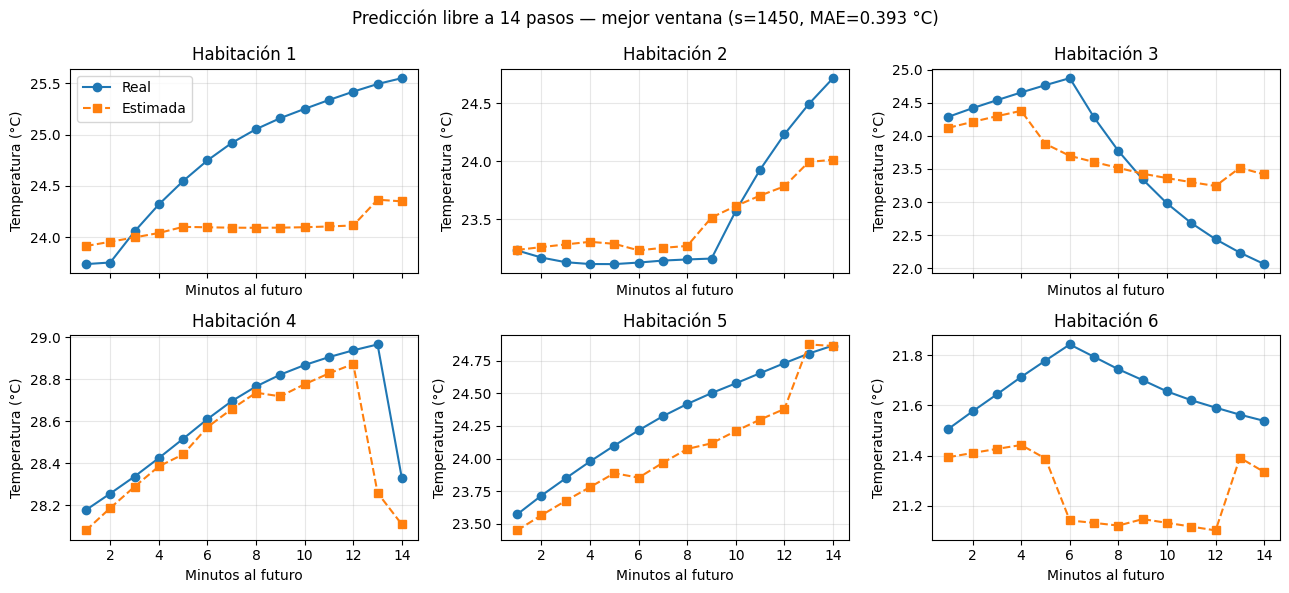

In [141]:
# Ventana con MEJOR desempeño: la de menor MAE de todas
mae_win = np.mean(np.abs(error), axis=(1, 2))
s_ej = int(np.argmin(mae_win))

horizonte = np.arange(1, H + 1)
fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True)
for r, ax in enumerate(axes.ravel()):
    ax.plot(horizonte, real_C[s_ej, :, r], 'o-',  label='Real')
    ax.plot(horizonte, pred_C[s_ej, :, r], 's--', label='Estimada')
    ax.set_title(f'Habitación {r + 1}')
    ax.set_xlabel('Minutos al futuro')
    ax.set_ylabel('Temperatura (°C)')
    ax.grid(alpha=0.3)
axes[0, 0].legend()
fig.suptitle(f'Predicción libre a 14 pasos — mejor ventana (s={s_ej}, MAE={mae_win[s_ej]:.3f} °C)')
plt.tight_layout()
plt.show()

### Cierre del objetivo

Con esto completamos el primer objetivo: desde el CSV obtenido por OPC-UA,
normalizamos los datos, identificamos un modelo lineal en espacio de estados con
N4SID, verificamos su estabilidad y lo evaluamos prediciendo 15 minutos al futuro
apoyándonos en el filtro de Kalman para fijar el estado inicial. Las métricas RMSE
y MAPE en °C resumen qué tan bien el modelo captura la dinámica térmica del edificio.